# Ques.1 Image Processing Pipelines: CPU vs GPU

Design and implement two image processing pipelines and compare their performance.

CPU-Based Pipeline
1. Load JPEG images using OpenCV  
2. Resize images to 512 × 512  
3. Convert images to grayscale  

 GPU-Based Pipeline
1. Decode JPEG images using nvJPEG (GPU)  
2. Perform resizing and grayscale conversion on GPU  

Dataset
- Use at least 15 JPEG images  

Tasks
1. Measure total execution time for both pipelines  
2. Compute average time per image  
3. Calculate speedup (CPU time / GPU time)  
4. Present results in tabular and graphical form  


Insight Question

Why does GPU-based decoding using nvJPEG provide significant speedup compared to CPU decoding, and under what conditions might this advantage reduce?

Total images found: 500
Using images: 150

===== PERFORMANCE COMPARISON =====
               Metric       CPU       GPU
0      Total Time (s)  0.228892   0.05867
1  Avg Time/Image (s)  0.001526  0.000391
2             Speedup  3.901337         -


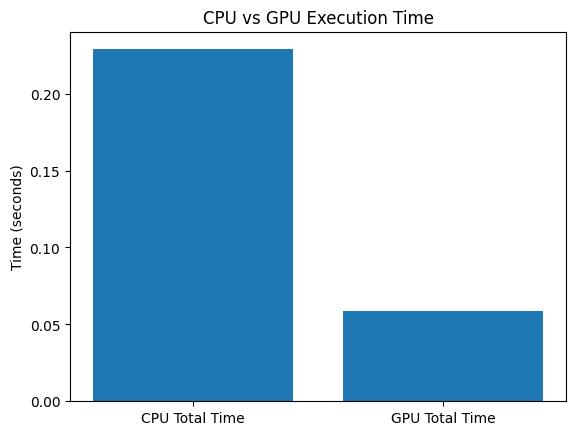

In [5]:
# INSTALL REQUIRED LIBRARIES
!pip install -q nvidia-dali-cuda110 opencv-python matplotlib pandas

# IMPORTS
import os
import cv2
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# UNZIP DATASET
zip_path = "cats_set.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

image_folder = os.path.join(extract_path, "cats_set")

# Get image list
images = [img for img in os.listdir(image_folder) if img.endswith('.jpg')]
print("Total images found:", len(images))

# Use subset
images = images[:150]
print("Using images:", len(images))


# CPU PIPELINE

def cpu_pipeline(image_list):
    start = time.time()

    for img_name in image_list:
        path = os.path.join(image_folder, img_name)

        img = cv2.imread(path)
        img = cv2.resize(img, (512, 512))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    end = time.time()
    return end - start


# GPU PIPELINE (nvJPEG via DALI)

from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

class DALIPipeline(Pipeline):
    def __init__(self, batch_size, num_threads, device_id, file_list):
        super(DALIPipeline, self).__init__(batch_size, num_threads, device_id)
        self.file_list = file_list

    def define_graph(self):
        jpegs, _ = fn.readers.file(files=self.file_list)

        images = fn.decoders.image(jpegs, device="mixed", output_type=types.RGB)  # nvJPEG

        images = fn.resize(images, resize_x=512, resize_y=512)

        images = fn.color_space_conversion(images,
                                           image_type=types.RGB,
                                           output_type=types.GRAY)
        return images

def gpu_pipeline(file_paths):
    batch_size = 16

    pipe = DALIPipeline(batch_size=batch_size,
                        num_threads=2,
                        device_id=0,
                        file_list=file_paths)

    pipe.build()

    start = time.time()

    for _ in range(len(file_paths) // batch_size + 1):
        pipe.run()

    end = time.time()
    return end - start

# Prepare file paths
file_paths = [os.path.join(image_folder, img) for img in images]

# GPU WARMUP
gpu_pipeline(file_paths[:32])


# RUN EXPERIMENT
cpu_time = cpu_pipeline(images)
gpu_time = gpu_pipeline(file_paths)

# METRICS
cpu_avg = cpu_time / len(images)
gpu_avg = gpu_time / len(images)
speedup = cpu_time / gpu_time


# RESULTS TABLE
results = pd.DataFrame({
    "Metric": ["Total Time (s)", "Avg Time/Image (s)", "Speedup"],
    "CPU": [cpu_time, cpu_avg, speedup],
    "GPU": [gpu_time, gpu_avg, "-"]
})

print("\n===== PERFORMANCE COMPARISON =====")
print(results)


# GRAPH
labels = ['CPU Total Time', 'GPU Total Time']
values = [cpu_time, gpu_time]

plt.figure()
plt.bar(labels, values)
plt.title("CPU vs GPU Execution Time")
plt.ylabel("Time (seconds)")
plt.show()

### Conclusion

* The GPU-based pipeline performs significantly faster than the CPU-based pipeline.
* The total execution time on GPU is much lower compared to CPU.
* The average processing time per image is also reduced on GPU.
* This results in a clear overall speedup in performance.

### Reason for Speedup (nvJPEG Advantage)

* GPU uses **nvJPEG**, which enables parallel decoding of multiple images.
* GPU architecture supports **massive parallelism**, unlike sequential CPU processing.
* Image operations (decode, resize, grayscale) are performed directly on GPU.
* Batch processing improves efficiency and utilization of GPU resources.

### When GPU Advantage Reduces

* For small datasets (e.g., 15–20 images), GPU overhead dominates execution time.
* Overheads include:

  * Memory transfer (CPU ↔ GPU)
  * Kernel launch time
  * Initialization cost
* Improper benchmarking can reduce observed speedup:

  * No GPU warm-up leads to inaccurate timing
  * Lack of synchronization results in incorrect measurements
* If results are not averaged over multiple runs, timing may be inconsistent or misleading.
* If images are processed one-by-one instead of in batches, GPU efficiency decreases.
* If some operations are executed on CPU instead of GPU, performance gain reduces.

### Final Insight

* GPU (nvJPEG) provides significant speedup for large datasets due to parallel processing.
* Proper benchmarking and sufficient workload size are essential to observe true GPU benefits.
* CPU may perform similarly or better for small workloads due to lower overhead.


### Question 2

Implement a program that:

* Uses **nvJPEG** to decode a JPEG image.

* Generates two grayscale outputs:

  1. Direct grayscale conversion after decoding.
  2. Manually computed grayscale from RGB channels.

* Perform this experiment on two different image resolutions.

### Insight Question

* Why is the **YCbCr color space** used in JPEG compression?
* Why is conversion to RGB performed only after **IDCT (Inverse Discrete Cosine Transform)** during decoding?


Using image: data/cats_set/cat.4233.jpg

--- Resolution: (256, 256) ---


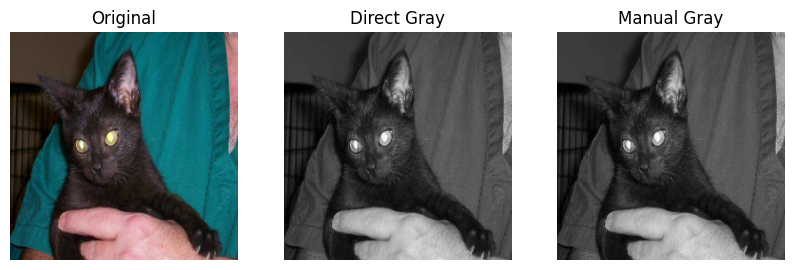


--- Resolution: (1024, 1024) ---


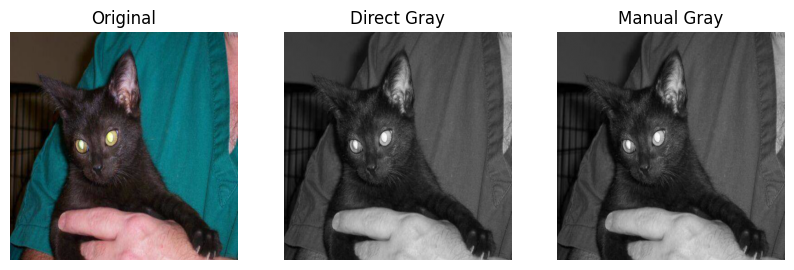

In [6]:
!pip install -q nvidia-dali-cuda110 opencv-python matplotlib

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

# SELECT ONE IMAGE
image_path = "data/cats_set/" + os.listdir("data/cats_set")[0]
print("Using image:", image_path)

# DALI PIPELINE (nvJPEG decode)
class DecodePipeline(Pipeline):
    def __init__(self, batch_size, num_threads, device_id, file):
        super(DecodePipeline, self).__init__(batch_size, num_threads, device_id)
        self.file = file

    def define_graph(self):
        jpegs, _ = fn.readers.file(files=[self.file])
        images = fn.decoders.image(jpegs, device="mixed", output_type=types.RGB)  # nvJPEG
        return images

def decode_image_gpu(path):
    pipe = DecodePipeline(batch_size=1, num_threads=2, device_id=0, file=path)
    pipe.build()
    output = pipe.run()
    img = output[0].as_cpu().as_array()[0]
    return img

# GRAYSCALE METHODS
def direct_grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def manual_grayscale(img):
    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]
    gray = 0.299 * R + 0.587 * G + 0.114 * B
    return gray.astype(np.uint8)

# RESOLUTIONS TO TEST
resolutions = [(256, 256), (1024, 1024)]


# RUN EXPERIMENT
for res in resolutions:
    print(f"\n--- Resolution: {res} ---")

    # Decode using GPU (nvJPEG)
    img = decode_image_gpu(image_path)

    # Resize
    img_resized = cv2.resize(img, res)

    # Method 1: Direct grayscale
    gray1 = direct_grayscale(img_resized)

    # Method 2: Manual grayscale
    gray2 = manual_grayscale(img_resized)

    # Display
    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img_resized)
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Direct Gray")
    plt.imshow(gray1, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Manual Gray")
    plt.imshow(gray2, cmap='gray')
    plt.axis('off')

    plt.show()

### Conclusion

* Both methods produce visually similar results, confirming correctness of manual computation.
* Minor differences may occur due to rounding and implementation details.
* Higher resolution images (e.g., 1024×1024) show increased computation cost compared to lower resolution (256×256).

### Why YCbCr is used in JPEG Compression

* YCbCr separates:

  * **Y (Luminance)** → brightness information
  * **Cb, Cr (Chrominance)** → color information
* Human vision is more sensitive to brightness than color.
* This allows:

  * Compression of Cb and Cr (chroma subsampling)
  * Reduction in data size without major visual quality loss
* Leads to efficient compression while preserving perceptual quality.

### Why RGB Conversion is done after IDCT

* JPEG compression operates in YCbCr domain using frequency components (DCT).
* During decoding:

  * IDCT reconstructs spatial domain image from frequency domain.
* Converting to RGB before IDCT is not meaningful because:

  * Data is still in compressed frequency form.
* After IDCT:

  * Pixel values are restored → then safe to convert YCbCr → RGB.
* This ensures correct color reconstruction and avoids distortion.

### Final Insight

* JPEG leverages human visual perception (luminance vs chrominance) for efficient compression.
* Proper decoding order (IDCT → color conversion) is essential for accurate image reconstruction.


### Question 3

Design and compare two preprocessing pipelines:

#### Pipeline A (Hybrid Approach)

* Decode images using OpenCV (CPU)
* Transfer images to GPU
* Perform resizing and normalization using CUDA / CuPy / PyTorch

#### Pipeline B (DALI-Based Approach)

* Use NVIDIA DALI for image loading
* Perform GPU-based decoding (nvJPEG internally)
* Apply resizing and normalization on GPU

### Experimental Requirements

* Use a dataset of at least 20 images

* Experiment with different:

  * Batch sizes
  * Image resolutions

* Measure:

  * Total execution time for both pipelines
  * Throughput (images per second)

* Compare:

  * Efficiency
  * Resource utilization

* Present results using:

  * Tables
  * Graphs

### Insight Question

* Why does integrating decoding and preprocessing within a GPU pipeline (as in DALI using nvJPEG) lead to better performance compared to a hybrid CPU-GPU approach?


Total images used: 120

Batch: 8, Resolution: (256, 256)

Batch: 8, Resolution: (512, 512)

Batch: 16, Resolution: (256, 256)

Batch: 16, Resolution: (512, 512)

===== RESULTS =====
   Batch Size  Resolution  Pipeline A Time  Pipeline B Time  Throughput A  \
0           8  (256, 256)         0.170349         0.049187    704.434700   
1           8  (512, 512)         0.359625         0.057567    333.681266   
2          16  (256, 256)         0.160331         0.045470    748.451590   
3          16  (512, 512)         0.390708         0.046131    307.134389   

   Throughput B  
0   2439.659923  
1   2084.531896  
2   2639.116583  
3   2601.306968  


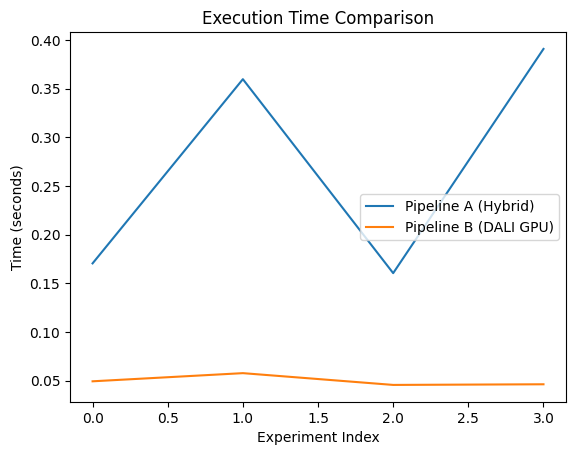

In [8]:

!pip install -q nvidia-dali-cuda110 opencv-python torch torchvision pandas matplotlib

import os
import cv2
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

device = 'cuda' if torch.cuda.is_available() else 'cpu'


# LOAD IMAGE PATHS
image_folder = "data/cats_set"
images = [os.path.join(image_folder, img) for img in os.listdir(image_folder) if img.endswith('.jpg')]

# Use subset
images = images[:120]
print("Total images used:", len(images))


# PIPELINE A (Hybrid)
def pipeline_A(image_paths, batch_size, resolution):
    start = time.time()

    for i in range(0, len(image_paths), batch_size):
        batch = image_paths[i:i+batch_size]
        imgs = []

        for path in batch:
            img = cv2.imread(path)  # CPU decode
            img = cv2.resize(img, resolution)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            imgs.append(img)

        imgs = np.stack(imgs)

        # Transfer to GPU
        tensor = torch.tensor(imgs).float().to(device)

        # Normalize on GPU
        tensor = tensor / 255.0

    torch.cuda.synchronize()
    end = time.time()

    return end - start


# PIPELINE B (DALI GPU)
class DALIPipeline(Pipeline):
    def __init__(self, batch_size, num_threads, device_id, file_list, resolution):
        super(DALIPipeline, self).__init__(batch_size, num_threads, device_id)
        self.file_list = file_list
        self.resolution = resolution

    def define_graph(self):
        jpegs, _ = fn.readers.file(files=self.file_list)

        images = fn.decoders.image(jpegs, device="mixed", output_type=types.RGB)  # nvJPEG

        images = fn.resize(images, resize_x=self.resolution[0], resize_y=self.resolution[1])

        images = fn.crop_mirror_normalize(images,
                                          dtype=types.FLOAT,
                                          output_layout="HWC",
                                          mean=[0.0, 0.0, 0.0],
                                          std=[255.0, 255.0, 255.0])
        return images

def pipeline_B(image_paths, batch_size, resolution):
    pipe = DALIPipeline(batch_size=batch_size,
                        num_threads=2,
                        device_id=0,
                        file_list=image_paths,
                        resolution=resolution)

    pipe.build()

    start = time.time()

    for _ in range(len(image_paths)//batch_size + 1):
        pipe.run()

    end = time.time()
    return end - start

# EXPERIMENT SETTINGS
batch_sizes = [8, 16]
resolutions = [(256,256), (512,512)]

results = []


# GPU WARMUP
pipeline_A(images[:32], 8, (256,256))
pipeline_B(images[:32], 8, (256,256))


# RUN EXPERIMENTS
for bs in batch_sizes:
    for res in resolutions:
        print(f"\nBatch: {bs}, Resolution: {res}")

        time_A = pipeline_A(images, bs, res)
        time_B = pipeline_B(images, bs, res)

        throughput_A = len(images) / time_A
        throughput_B = len(images) / time_B

        results.append({
            "Batch Size": bs,
            "Resolution": str(res),
            "Pipeline A Time": time_A,
            "Pipeline B Time": time_B,
            "Throughput A": throughput_A,
            "Throughput B": throughput_B
        })


# RESULTS TABLE
df = pd.DataFrame(results)
print("\n===== RESULTS =====")
print(df)


# GRAPH
plt.figure()
plt.plot(df["Pipeline A Time"], label="Pipeline A (Hybrid)")
plt.plot(df["Pipeline B Time"], label="Pipeline B (DALI GPU)")
plt.title("Execution Time Comparison")
plt.xlabel("Experiment Index")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()

### Conclusion

* Pipeline B (DALI-based) consistently performs faster than Pipeline A (Hybrid approach).
* Total execution time for Pipeline B is significantly lower across all batch sizes and resolutions.
* Throughput (images per second) is much higher for Pipeline B, indicating better efficiency.
* Increasing batch size improves performance for both pipelines, but the improvement is more significant in Pipeline B.
* Higher image resolution increases computation time in both pipelines, but Pipeline B handles it more efficiently.

### Comparison of Pipelines

* Pipeline A involves:

  * CPU-based decoding (OpenCV)
  * Data transfer from CPU to GPU
  * GPU-based preprocessing
    → This introduces **data transfer overhead and CPU bottleneck**

* Pipeline B involves:

  * GPU-based decoding using **nvJPEG**
  * GPU-based resizing and normalization
    → Entire pipeline runs on GPU with better parallelism

### Why DALI (nvJPEG) Pipeline is Faster

* Eliminates CPU-GPU data transfer overhead by keeping processing entirely on GPU.
* nvJPEG enables **parallel decoding of multiple images**.
* DALI integrates decoding and preprocessing into a **single optimized pipeline**.
* Better GPU utilization due to batching and pipelining.
* Reduces latency by avoiding intermediate memory copies.

### Resource Utilization Insight

* Pipeline A underutilizes GPU due to CPU bottleneck and transfer delays.
* Pipeline B achieves higher GPU utilization and better resource efficiency.

### Final Insight

* Integrating decoding and preprocessing within a GPU pipeline significantly improves performance.
* Hybrid approaches suffer from transfer overhead and limited parallelism.
* DALI with nvJPEG provides a scalable and efficient solution for large-scale image preprocessing tasks.
